<a href="https://colab.research.google.com/github/jirvingphd/ai-aoe-workshop-backup/blob/main/notebooks_fixed_vers/(AICOE_Workshop_04)_Retrieval_Augmented_Generation_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retrieval Augmented Generation Systems (RAGs)

## Introduction



In this notebook, we will explore **Retrieval-Augmented Generation (RAG)**, a powerful technique that combines the strengths of **retrieval-based systems** and **generative models** to provide accurate, contextually relevant, and detailed responses to user queries.


### Overview of RAG systems


At its core, a RAG system enhances the capabilities of a generative model (like GPT or similar LLMs) by integrating it with a **retrieval mechanism**. Here's how it works:

1. **Retrieval Component**:
   - RAG systems query a knowledge base (e.g., vector databases, document stores, or APIs) to retrieve relevant context or supporting documents.
   - This allows the system to ground its responses in factual and specific data, reducing hallucinations and improving reliability.

2. **Generative Component**:
   - After retrieving the relevant context, a generative model synthesizes a response based on both the query and the retrieved data.
   - This ensures that the output is not only accurate but also coherent and natural-sounding.


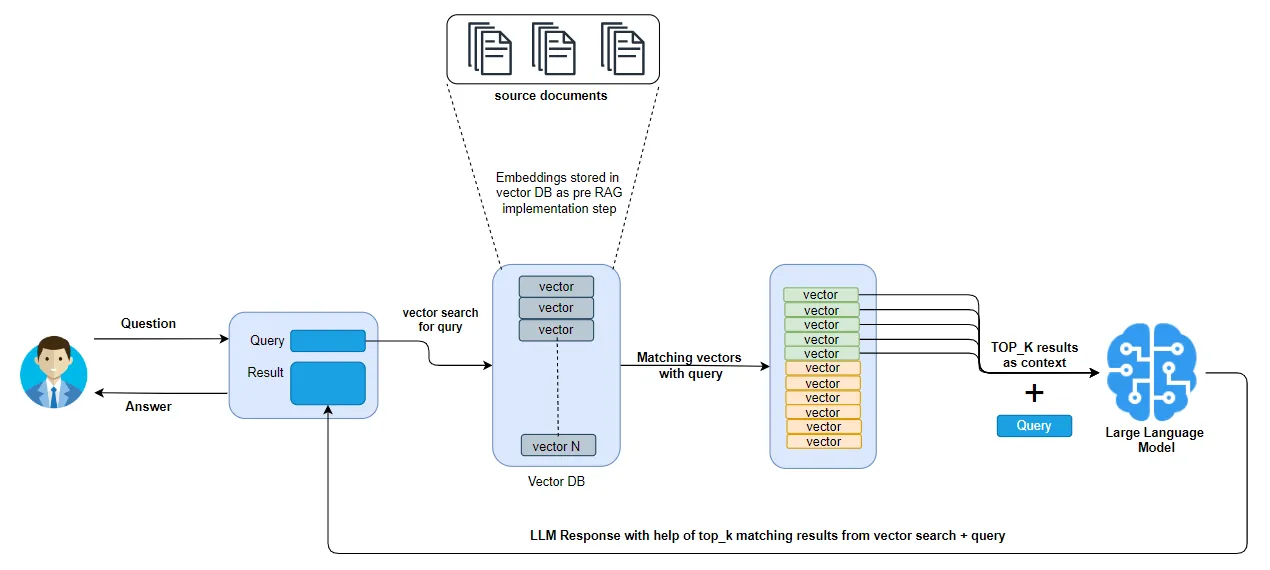

<center><a href="https://medium.com/@ashpaklmulani/improve-retrieval-augmented-generation-rag-with-re-ranking-31799c670f8e">Image Source</a></center>


### Why RAG Matters

While large language models (LLMs) are highly capable, they are limited by their training data. They cannot access or leverage information that:
- Was introduced after the training cutoff date.
- Resides in proprietary or dynamic datasets specific to an organization or domain.

RAG systems address this limitation by dynamically incorporating external knowledge into the generation process. They are especially valuable in applications requiring:
- Domain-specific knowledge (e.g., legal, healthcare, or financial sectors).
- Frequently updated information (e.g., news or live event tracking).
- Customized answers tailored to user queries in real-time.


### RAG's Importance in Today's World



In an era where information is abundant and constantly evolving, Retrieval-Augmented Generation (RAG) systems play a critical role in bridging the gap between static, pre-trained models and the dynamic, real-world information needs of users. Traditional generative models are powerful but have limitations when it comes to:
- **Outdated knowledge**: LLMs are trained on static datasets that might not include the most recent developments or specialized data.
- **Factual accuracy**: Generative models can sometimes "hallucinate," providing confident but incorrect or fabricated responses.

RAG systems address these challenges by combining the reasoning and language capabilities of generative models with the precision of real-time information retrieval. By grounding their outputs in up-to-date, verified data sources, RAG systems ensure that responses are:
- **Accurate and reliable**: Answers are based on the most relevant and factual information.
- **Contextually rich**: Responses incorporate domain-specific insights, tailored to the user's query.
- **Adaptable to new knowledge**: Retrieval allows RAG systems to remain relevant, even in fast-changing fields like medicine, finance, and technology.

This makes RAG a cornerstone technology in modern AI applications, ensuring that AI systems are not just capable of generating text but doing so with relevance and precision.



### Real-World Industry Examples Where RAG Systems Are Used



RAG systems are already transforming a variety of industries by enabling AI applications to provide grounded, insightful, and actionable information. Here are a few key examples:

| **Industry**          | **Use Case**                     | **How RAG is Applied**                                                                      |
|------------------------|-----------------------------------|--------------------------------------------------------------------------------------------|
| **Healthcare**         | Medical decision support systems | Retrieves information from medical databases, research papers, and clinical guidelines to assist healthcare professionals in diagnosing and recommending treatments. |
| **E-Commerce**         | Personalized product recommendations | Combines user queries with real-time product catalog data for tailored shopping suggestions or answers to product-related questions. |
| **Legal Industry**     | Legal research assistants        | Retrieves case law, statutes, and regulations for quick access to relevant legal information. |
| **Customer Support**   | Intelligent virtual assistants   | Pulls support documentation and FAQs to provide accurate, context-aware customer responses. |
| **Education and Research** | Academic research assistants      | Summarizes and extracts insights from textbooks, research papers, and scholarly articles.   |
| **Financial Services** | Market analysis and risk assessment | Analyzes real-time financial data and news to generate insights for traders and analysts.    |

By enabling AI systems to retrieve and incorporate domain-specific, real-time data, RAG systems are shaping the future of industries that require accurate, context-sensitive, and reliable information.


## File Ingestion & Vector Indexing

**File ingestion** is the process of loading documents, breaking them into chunks, and converting the chunks into vectors using an embedding model.


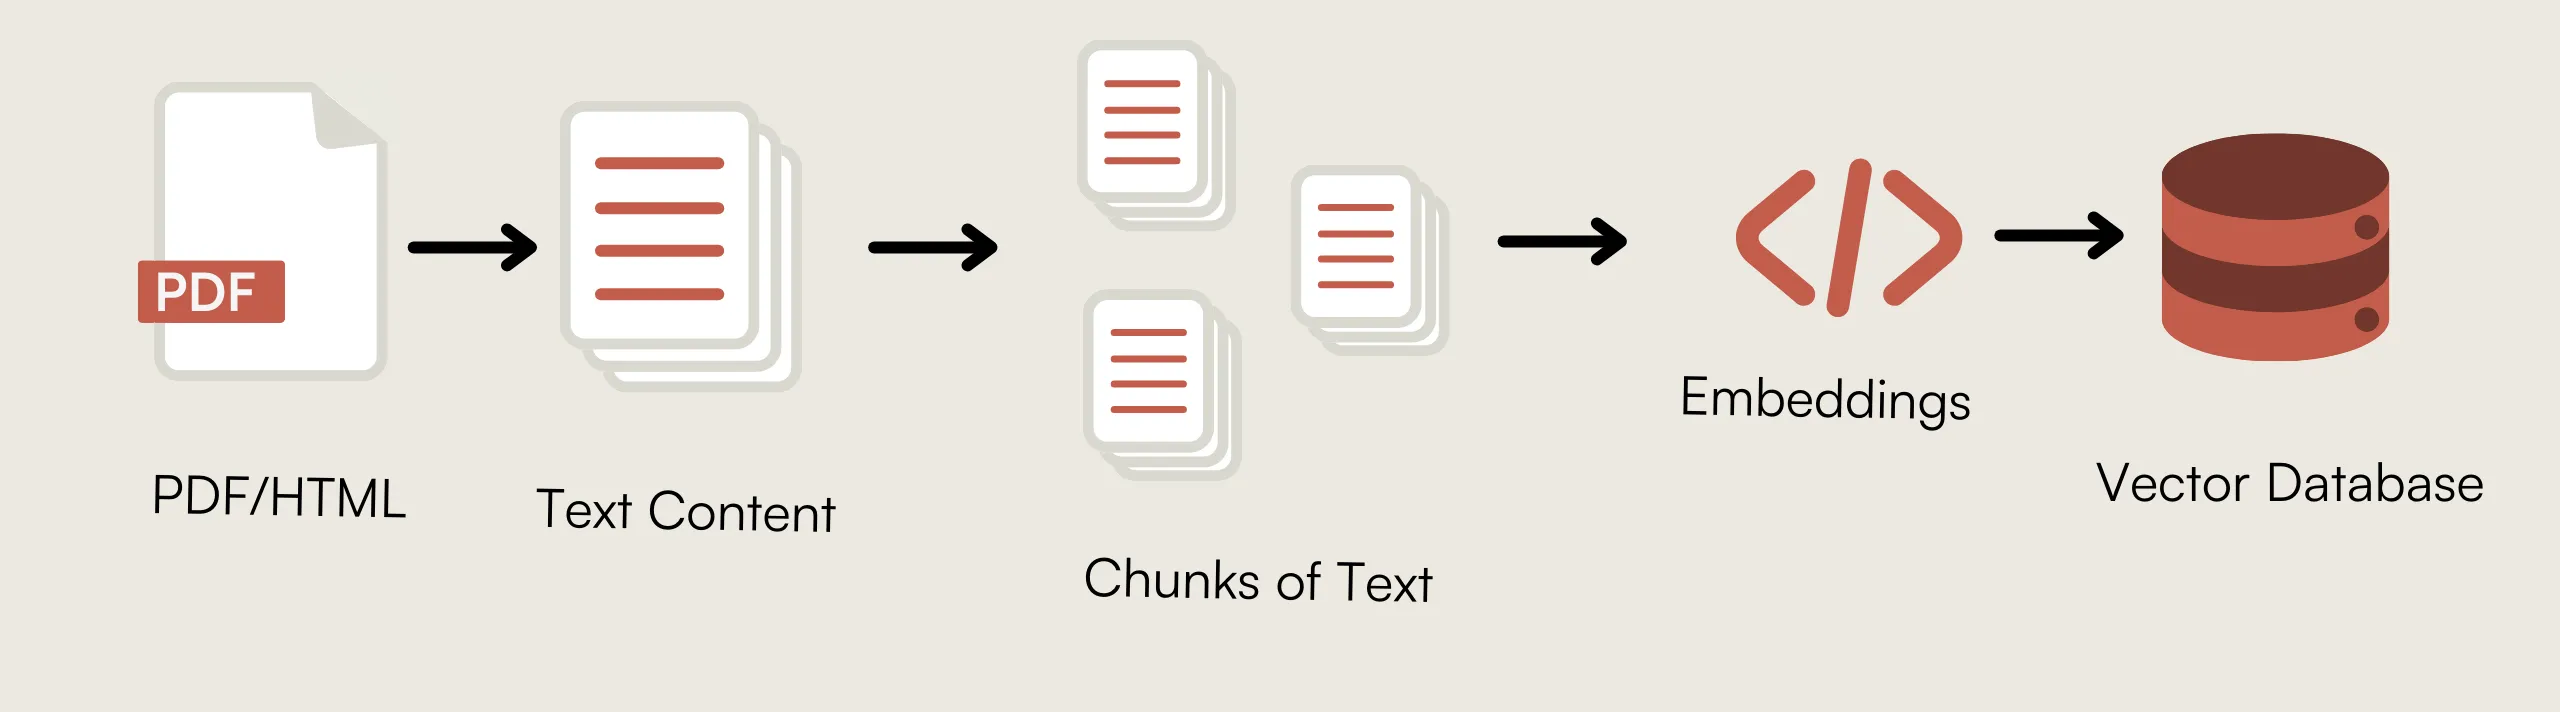



Vectorized representations of document chunks are numeric representations of the semantic meaning of the document. We will perform a similarity search between the user's query and the entries in the vector database.

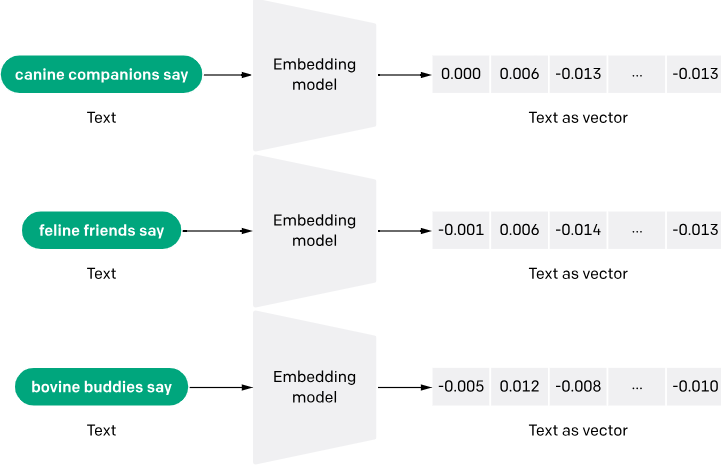

**Dataset**: sec-10-q

A collection of 20 Quarterly SEC filings by Amazon, Microsoft, Nvidia, etc.

Quarterly SEC filings (Form 10-Q) contain a company’s unaudited financial statements, management discussion of financial conditions, and disclosures on market risks, legal proceedings, and internal controls. They provide investors with an update on the company's financial performance and any material events since the last annual report.

- [Source: GitHug](https://github.com/docugami/KG-RAG-datasets/tree/main/sec-10-q)

- [Zip File to Upload to Colab](https://drive.google.com/file/d/1-8QLZjqsyd34MXEzRs3PePjtFBsbxFSi/view?usp=drive_link)




> Upload the zip file using Colab's Files sidebar.

In [10]:
## Import data
!unzip -o /content/workshop4-files-sec.zip -d /content/data/

Archive:  /content/workshop4-files-sec.zip
 extracting: /content/data/docs/2022 Q3 AAPL.pdf  
 extracting: /content/data/docs/2022 Q3 AMZN.pdf  
 extracting: /content/data/docs/2022 Q3 INTC.pdf  
 extracting: /content/data/docs/2022 Q3 MSFT.pdf  
 extracting: /content/data/docs/2022 Q3 NVDA.pdf  
 extracting: /content/data/docs/2023 Q1 AAPL.pdf  
 extracting: /content/data/docs/2023 Q1 AMZN.pdf  
 extracting: /content/data/docs/2023 Q1 INTC.pdf  
 extracting: /content/data/docs/2023 Q1 MSFT.pdf  
 extracting: /content/data/docs/2023 Q1 NVDA.pdf  
 extracting: /content/data/docs/2023 Q2 AAPL.pdf  
 extracting: /content/data/docs/2023 Q2 AMZN.pdf  
 extracting: /content/data/docs/2023 Q2 INTC.pdf  
 extracting: /content/data/docs/2023 Q2 MSFT.pdf  
 extracting: /content/data/docs/2023 Q2 NVDA.pdf  
 extracting: /content/data/docs/2023 Q3 AAPL.pdf  
 extracting: /content/data/docs/2023 Q3 AMZN.pdf  
 extracting: /content/data/docs/2023 Q3 INTC.pdf  
 extracting: /content/data/docs/2023 Q3

In [ ]:
# Install Libraries
# 08/08/25 - exact versions added
!pip install openai==1.98.0
!pip install langchain==0.3.27
!pip install langchain-openai==0.3.28
!pip install langchain-community==0.3.27
!pip install chromadb==1.0.16
!pip install lark==1.2.2
!pip install pypdf==5.9.0
!pip install cohere==5.16.2
!pip install rank-bm25==0.2.2
!pip install langchain-cohere==0.4.5
!pip install faiss-cpu==1.11.0.post1

In [3]:
## Import all relevant libraries
from langchain_community.document_loaders import TextLoader, PyPDFLoader, WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter, HTMLHeaderTextSplitter, RecursiveJsonSplitter
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.runnables import RunnablePassthrough
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.output_parsers.string import StrOutputParser
from langchain.chains.query_constructor.schema import AttributeInfo
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import BaseOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain.chains import create_history_aware_retriever
from langchain_core.prompts import MessagesPlaceholder
from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain.vectorstores import FAISS
from langchain_community.embeddings import CohereEmbeddings
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank
from langchain_community.llms import Cohere
from langchain import hub
from langchain.chains import RetrievalQA
import warnings
from google.colab import userdata
import os
import glob, re
from tqdm.auto import tqdm
import logging
from typing import List

warnings.filterwarnings("ignore")

> **Using Google Colab's secrets management sidebar for our API key.**

Google Colab now includes a secrets management menu on the sidebar (the key icon).

- Open the secrets sidebar
- Add a new secret
- Use `OPENAI_API_KEY` as the Name and paste your API key as the value.
- Make sure to toggle the Notebook Access switch to On.

Now, we can use the code snippet below to grab the OPENAI_API_KEY from our secrets manager and save it to our environment so that its available for LangChain.

In [4]:
## API Key from Secrets sidebar
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

## Alternative Way - Paste in Key with getpass
# from getpass import getpass
# #Define an OpenAI API Key
# os.environ['OPENAI_API_KEY'] = getpass('Enter the OpenAI API key value: ')
# print("Successfully assigned an OpenAI API Key!")

To load the entire collection of documents, we will first save their filepaths using the `glob` module.

In [11]:
# Get filepaths of all pdf docs
files = sorted(glob.glob('/content/data/docs/*.pdf'))
files[:5]

['/content/data/docs/2022 Q3 AAPL.pdf',
 '/content/data/docs/2022 Q3 AMZN.pdf',
 '/content/data/docs/2022 Q3 INTC.pdf',
 '/content/data/docs/2022 Q3 MSFT.pdf',
 '/content/data/docs/2022 Q3 NVDA.pdf']

We want to add some additional metadata to the Document objects. We can extract the year, quarter, and company stock symbol using regular expressions.

In [12]:
# Using RegEx to extract metadata from the filename
expr = r"(\d{4,}) (Q[1,2,3,4]) (\w{4,})"
re.findall(expr, files[0])

[('2022', 'Q3', 'AAPL')]

We will use the `PyPDFLoader` to load our PDFs as Document objects. We will use the `RecursiveCharacterTextSplitter` to split the Documents into smaller chunks 500-tokens-long. We introduced these tools in the previous workshop.

In [ ]:
# Load the PDFs as Documents

final_documents = []
for file in tqdm(files):
    # Load docs with PyPDF
    loader = PyPDFLoader(file)
    docs = loader.load()

    # Adding metadata from file name
    a = re.findall(expr, os.path.basename(file))
    year, quarter, company = a[0]
    for doc in docs:
        doc.metadata.update(**{'year':year,
                               'quarter':quarter,
                               'company':company})

    # Define a RecursiveCharacterTextSplitter object with the relevant input parameters
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    docs = text_splitter.split_documents(docs)

    # Save the split documents
    final_documents.extend(docs)
len(final_documents)

### Different File-Ingestion Techniques



In order to construct our vector database, we need to first load the documents from their original source.

There are document loaders for a large selection of sources:
- PDFs
- Webpages
- CSVs
- JSON
- HTML
- Cloud Services (AWS, Dropbox, Azure, GCP, OneDrive, SharePoint, etc.)
- Social Platforms (Twitter/X, Reddit)
- Messaging Services (Telegram, WhatsApp, Discord, Facebook, Mastadon)
- Productivity Tools (Figma, Notion, Slack, Trello, GitHub, etc.)
- YouTube Audio/Transcripts

These document loaders are often created by the community and not from LangChain themselves. Consequently there are multiple options for some forms of documents. For example, there are 10 PDF loaders available in the `langchain_community` package that leverage different tools for the text extraction. If you have poor results using a document loader, you should consider trying an alternative option to see if it performs better for your corpus.


There are many LangChain tools available for document loading. For a comprehensive list, see [this documentation page](https://python.langchain.com/docs/integrations/document_loaders/).

In [14]:
# Preview Document metadata and content
print(final_documents[0].metadata)
print(final_documents[0].page_content[:1000])

{'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0', 'creator': 'EDGAR Filing HTML Converter', 'creationdate': '2022-07-29T06:03:21-04:00', 'title': '0000320193-22-000070', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions', 'subject': 'Form 10-Q filed on 2022-07-29 for the period ending 2022-06-25', 'keywords': '0000320193-22-000070; ; 10-Q', 'moddate': '2022-07-29T06:03:28-04:00', 'source': '/content/data/docs/2022 Q3 AAPL.pdf', 'total_pages': 28, 'page': 0, 'page_label': '1', 'year': '2022', 'quarter': 'Q3', 'company': 'AAPL'}
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
FORM 10-Q
(Mark One)
☒  QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the quarterly period ended June 25, 2022
or
☐  TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the transition period from              to             .
Commission File Number: 001-36743
Apple Inc.
(Exact name of R

In [15]:
#Embed the text into a numerical vector of a specified dimension
embeddings = OpenAIEmbeddings(model="text-embedding-3-large", dimensions = 1024)

# Define a vector store DB
db = Chroma.from_documents(final_documents, embeddings,
                           persist_directory='/content/chroma_db')
db

In [16]:
# Create a retriever object from the vector db
retriever = db.as_retriever(search_kwargs={'k': 3})
retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7ea7cfef84d0>, search_kwargs={'k': 3})

In [17]:
# Test document retrieval
q = "What was Apple's total net sales for June, 2022?"
docs = retriever.invoke(q)
len(docs)

3

In [18]:
# View the retrieved docs
docs

[Document(metadata={'total_pages': 28, 'creationdate': '2022-07-29T06:03:21-04:00', 'creator': 'EDGAR Filing HTML Converter', 'quarter': 'Q3', 'source': '/content/data/docs/2022 Q3 AAPL.pdf', 'subject': 'Form 10-Q filed on 2022-07-29 for the period ending 2022-06-25', 'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0', 'page': 17, 'keywords': '0000320193-22-000070; ; 10-Q', 'title': '0000320193-22-000070', 'page_label': '18', 'year': '2022', 'company': 'AAPL', 'moddate': '2022-07-29T06:03:28-04:00', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions'}, page_content='Three Months Ended Nine Months Ended\nJune 25,2022 June 26,2021 Change June 25,2022 June 26,2021 Change\nNet sales by category:\niPhone $ 40,665 $ 39,570 3 % $ 162,863 $ 153,105 6 %\nMac 7,382 8,235 (10)% 28,669 26,012 10 %\niPad 7,224 7,368 (2)% 22,118 23,610 (6)%\nWearables, Home and Accessories 8,084 8,775 (8)% 31,591 29,582 7 %\nServices 19,604 17,486 12 % 58,941 50,148 18 %\nTotal net sales $ 82,959 $ 

## Basic RAG Implementation

For our first RAG implementation, we will ask the user **query**, which gets transformed into a text embedding using the **embedding model**.

A similarity search is then performed comparing the user query's vector with the vectors stored in the **vector store index**.

After calcualting the most similar vectors, the corresponding raw text for the most similar vectors is retrieved from the text **database** and passed into the LLM as **context**. The **LLM** then uses the provided context to answer the original query.

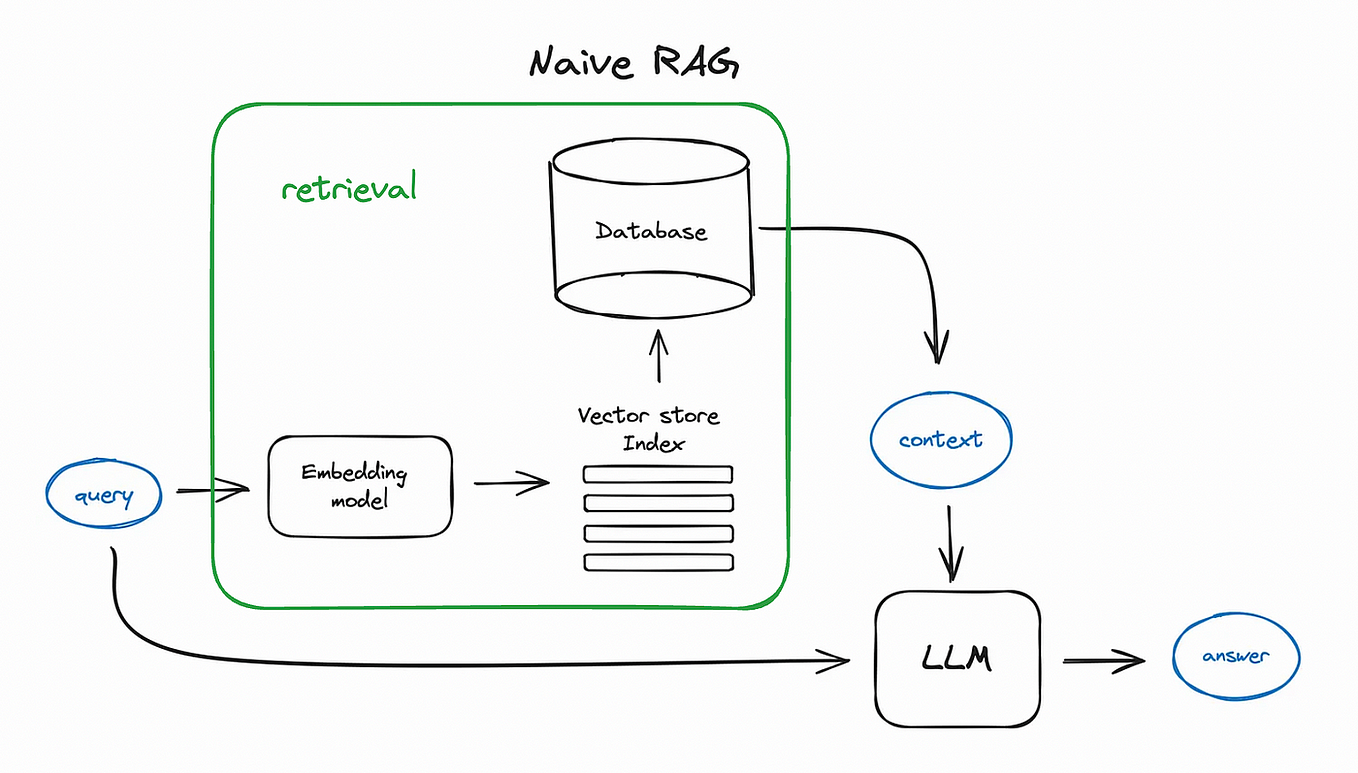


<center><a href="https://miro.medium.com/v2/resize:fit:1358/1*_GK5dZzLKOab6i48sJdGdw.png"> Image Source</a></center>

For the most basic implementation of RAG, we will leverage a [pre-constructed prompt from LangChain Hub](https://smith.langchain.com/hub/rlm/rag-prompt).

LangChain Hub is a centralized platform for uploading, browsing, and managing prompts, chains, agents, and other components used in building applications powered by large language models. It facilitates sharing and discovering workflows, enabling developers to collaborate and access a repository of commonly used artifacts. ([blog.langchain.dev](https://blog.langchain.dev/langchainhub/?utm_source=chatgpt.com))


In [19]:
# Instantiate the LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# Define prompt for question-answering
prompt = hub.pull("rlm/rag-prompt")
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [20]:
# Viewing the prompt's messages
prompt.messages

[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]

This prompt includes 2 input variables: "context" and "question".

In [21]:
# Prompt includes 2 inputs
prompt.input_variables

['context', 'question']

To construct RAG chain, we will use LangChain Expression Language (LCEL), which uses pipe symbols (`|`) to connect the various components into a chain. All LangChain chains are created with LCEL, even if we leverage a higher-level helper function (e.g. `create_stuff_documents_chain`).

We include a dictionary with the two input variables for the prompt: </br>
> Context - Formatted result of the retriever </br>
> Question -  User query, which will be passed into the chain via a RunnablePassthrough object





In the below code snippet: </br>

`retriever | format_docs` - Retrieves documents and then formats them appropriately for use in the next stages of the pipeline.</br>

`RunnablePassthrough()` - Passes the question input through unchanged, allowing it to be used later in the pipeline without modification.




In [22]:
#Adapted from source: https://python.langchain.com/docs/how_to/qa_sources/

def format_docs(docs):
    """Join document contents together"""
    return "\n\n".join(doc.page_content for doc in docs)

## Creating our basic rag chain using LCEL
rag_chain = (
    {'context': retriever | format_docs, 'question':RunnablePassthrough()} # Inputs for prompt
    | prompt
    | llm
    | StrOutputParser()
)
rag_chain

{
  context: VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7ea7cfef84d0>, search_kwargs={'k': 3})
           | RunnableLambda(format_docs),
  question: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])
| ChatOpenAI(client=<

RAG chains are invoked the same way as a standard chain.

In [23]:
# Invoking the rag chain with a test question
q = "What was Apple's total net sales for June, 2022?"
rag_chain.invoke(q)

"Apple's total net sales for June 2022 were $82,959 million."

## Context Fulfillment

**Context Fulfillment** is a process by which an LLM enhances vague prompts using information from the conversation's history.

For example, if the user first asked the LLM to provide an explanation for Retrieval Augmented Generation and then asked a follow-up question such as "Give me some examples of how it is used". With context fulfillment, the "it" would be replaced with details from the prior question. It would become "Give me some examples of how RAG is used." This ensures that the query used for retrieval contains the key words relevant to question.

To use context fulfillment, we first have to track the conversation history and pass it into the LLM as part of the prompt.


### Constructing Context Fulfillment Chain

LangChain includes some convenience functions for creating chains without using LCEL directly, which we will use below to create our context fulfillment chain.

- We will first use the `create_history_aware_retriever` function below to create the retriever that includes context fulfillment.

- We will then create a chain for answering questions with documents using `create_stuff_documents_chain`.

- Finally, we will use `create_retrieval_chain` to combine the two into one final chain with context fulfillment implemented.

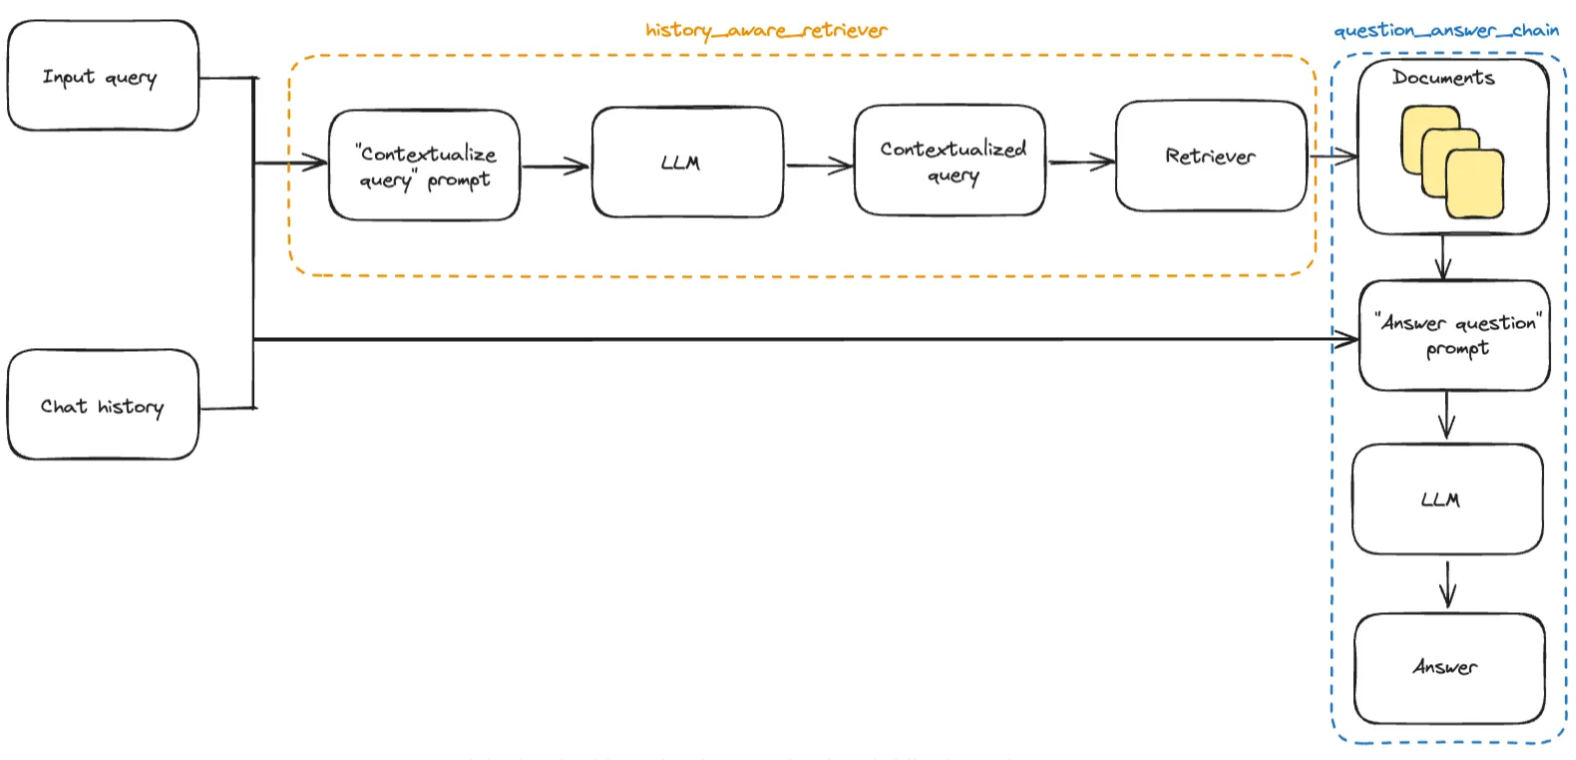

In [24]:
## Create history_aware_retriever
# https://python.langchain.com/v0.2/docs/tutorials/qa_chat_history/#adding-chat-history

# Instantiate LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# Context fulfillment prompt
contextualize_q_system_prompt = (
    "Given a chat history and the latest user question "
    "which might reference context in the chat history, "
    "formulate a standalone question which can be understood "
    "without the chat history. Do NOT answer the question, "
    "just reformulate it if needed and otherwise return it as is."
)

# Construct prompt template
contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt), # System prompt
        MessagesPlaceholder("chat_history"), # Placeholder for chat_history.
        ("human", "{input}"), # Human query
    ]
)

# Use convenience function to create history-aware retriever
history_aware_retriever = create_history_aware_retriever(
    llm, retriever, contextualize_q_prompt
)

In [25]:
## Construct q&a chain with create_stuff_documents_chain

# Q&A prompt
system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

# Construct prompt template
qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt), # System prompt
        MessagesPlaceholder("chat_history"), # Placeholder for chat_history.
        ("human", "{input}"),  # Human query
    ]
)

# Use convenience function to create Q&A chain
question_answer_chain = create_stuff_documents_chain(llm, qa_prompt )


## Combine the history_aware_retriever and quesion_answer chain into one final chain
rag_chain = create_retrieval_chain(history_aware_retriever, question_answer_chain)

In [26]:
# All of these objects are constructed with LCEL under-the-hood
rag_chain

RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableBinding(bound=RunnableBranch(branches=[(RunnableLambda(lambda x: not x.get('chat_history', False)), RunnableLambda(lambda x: x['input'])
           | VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7ea7cfef84d0>, search_kwargs={'k': 3}))], default=ChatPromptTemplate(input_variables=['chat_history', 'input'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], ty

In [27]:
## Using the combined context fulfillment chain

# Instantiate blank chat_history
chat_history = ChatMessageHistory()

# Ask a specific first question
q = "What was Amazon's net sales for Q2 of 2022?"
response = rag_chain.invoke({'input':q,
                             "chat_history":chat_history.messages # Must pass in chat history messages manually
                             })

# The combined chain returns a dictionary
display(response.keys())
print(response['answer'])

dict_keys(['input', 'chat_history', 'context', 'answer'])

Amazon's net sales for Q2 of 2022 were $121,234 million.


In [28]:
# Chat History needs to be manually updated
chat_history.add_user_message(q)
chat_history.add_ai_message(response['answer'])
chat_history.messages

[HumanMessage(content="What was Amazon's net sales for Q2 of 2022?", additional_kwargs={}, response_metadata={}),
 AIMessage(content="Amazon's net sales for Q2 of 2022 were $121,234 million.", additional_kwargs={}, response_metadata={})]

In [29]:
## Ask a vague follow up question
q = "What about Q3?"
response = rag_chain.invoke({'input':q, "chat_history":chat_history.messages})

# Manually updating chat history
chat_history.add_user_message(q)
chat_history.add_ai_message(response['answer'])

print(response['answer'])

Amazon's net sales for Q3 of 2022 were $127,101 million.


## Query Rewriting

### What is Query Rewriting?


**Query Rewriting** refers to the process of modifying or optimizing a user’s original query to improve the relevance, accuracy, or completeness of the information retrieved from external data sources before generating a response.

This step is critical in ensuring that the retrieval component of a RAG pipeline fetches the most relevant context from the knowledge base or vector store, which can then be used to enhance the generation phase.

Two example forms of query rewriting are **query expansion** and **query decomposition**.

#### Query Expansion

With **query expansion**, a LLM produces a set of similar queries to the original user query, but from different perspectives. Documents are retrieved for each of the generated queries and fed into the LLM for generating the final answer.

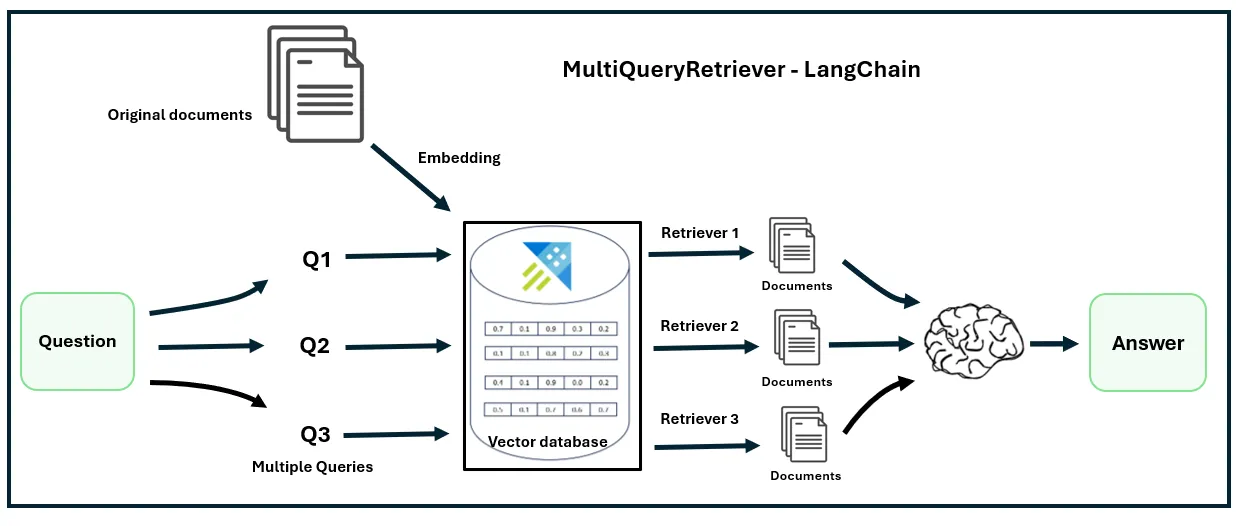
<center><a href="https://medium.com/@kbdhunga/advanced-rag-multi-query-retriever-approach-ad8cd0ea0f5b">Image Source</a></center>

In [30]:
## Code Implementation - LangChain's MultiQueryRetriever
# Adapted from source: https://python.langchain.com/docs/how_to/MultiQueryRetriever/


llm = ChatOpenAI(temperature=0, model='gpt-4o-mini')

# Create MultiQueryRetriever set to retriever 3 documents
retriever_from_llm = MultiQueryRetriever.from_llm(
    retriever = db.as_retriever(search_kws={"k":3}), llm=llm)
retriever_from_llm

MultiQueryRetriever(retriever=VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7ea7cfef84d0>, search_kwargs={}), llm_chain=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='You are an AI language model assistant. Your task is\n    to generate 3 different versions of the given user\n    question to retrieve relevant documents from a vector  database.\n    By generating multiple perspectives on the user question,\n    your goal is to help the user overcome some of the limitations\n    of distance-based similarity search. Provide these alternative\n    questions separated by newlines. Original question: {question}')
| ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x7ea7b1835e90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7ea7b1836f50>, root_client=<openai.OpenAI object at 0x7ea7ca

In order to see the rewritten prompts, we will need to enable logging using Python's built-in logging module.

In [31]:
# Adapted from source: https://python.langchain.com/docs/how_to/MultiQueryRetriever/

# Set logging for the rewritten queries
logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

In [32]:
# Testing the rewritten queries with our previous question
unique_docs = retriever_from_llm.invoke(q)
len(unique_docs)

INFO:langchain.retrievers.multi_query:Generated queries: ['What can you tell me regarding Q3?  ', 'Can you provide information or insights on Q3?  ', 'What are the details or context surrounding Q3?']


7

Thanks to Python logging we can see the 3 expanded queries. Notice that we received 6 documents from the retriever. These are the unique documents from the 8 total documents (3 docs x 3 queries).


Let's construct our rag chain using our query expansion retriever.

In [33]:
# Construct complete chain with RAG
def format_docs(docs):
    """Join document contents together"""
    return "\n\n".join(doc.page_content for doc in docs)

# Construct rag chain using MultiQueryRetriever
rag_chain_multi = (
    {'context': retriever_from_llm | format_docs, 'question':RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)


In [34]:
# Use the query expansion rag chain
q = "What was Amazon's net sales for Q2 of 2022?"
rag_chain_multi.invoke(q)

INFO:langchain.retrievers.multi_query:Generated queries: ["What were Amazon's total revenues for the second quarter of 2022?  ", 'Can you provide the net sales figures for Amazon in Q2 2022?  ', 'How much did Amazon earn in net sales during the second quarter of 2022?']


"Amazon's net sales for Q2 of 2022 were $121,234 million. This total includes net product sales of $56,575 million and net service sales of $64,659 million."

#### Query Decomposition

With **query decomposition**, a LLM breaks the user query into smaller/simpler sub-queries. Documents are retrieved for each of the generated queries and fed into the LLM for generating the final answer.


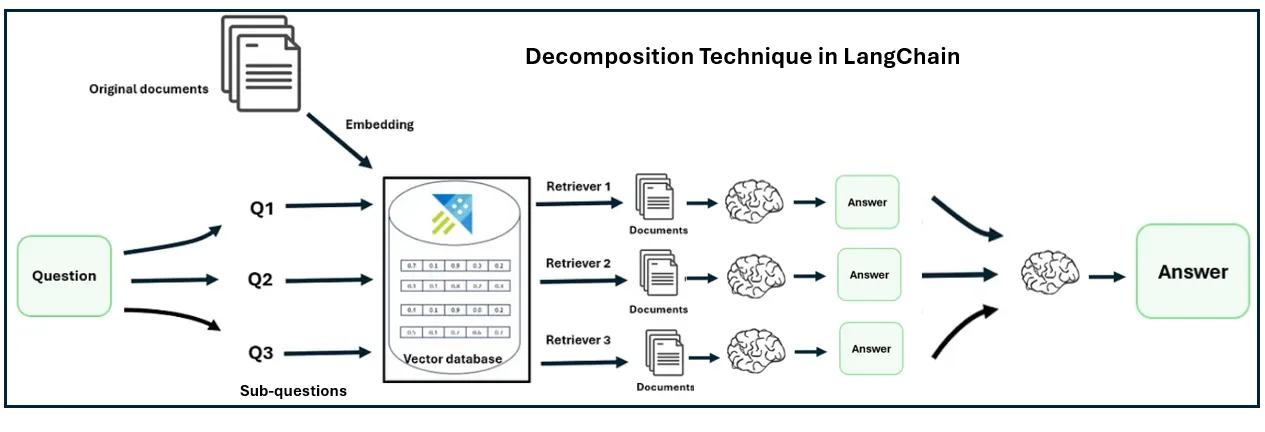
<center><a href="https://medium.com/@kbdhunga/advanced-rag-decomposition-technique-in-langchain-c0959541cfec">Image Source</a></center>

In [35]:
# Adapted from source: https://python.langchain.com/docs/how_to/MultiQueryRetriever/

# Output parser will split the LLM result into a list of queries
class LineListOutputParser(BaseOutputParser[List[str]]):
    """Output parser for a list of lines."""

    def parse(self, text: str) -> List[str]:
        lines = text.strip().split("\n")
        return list(filter(None, lines))  # Remove empty lines

output_parser = LineListOutputParser()


In [36]:
# Template source: https://medium.com/@kbdhunga/advanced-rag-decomposition-technique-in-langchain-c0959541cfec
template =  """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answered in isolation. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""

prompt = PromptTemplate(
    input_variables=["question"],
    template=template
)
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")

# Chain
decomp_chain = prompt | llm | output_parser

In [37]:
## Code Implementation - LangChain's MultiQueryRetriever + Custom Decomposition Prompt
retriever_decomp = MultiQueryRetriever(
    retriever=db.as_retriever(search_kws={"k":3}), llm_chain=decomp_chain,
    parser_key="lines" # "lines" is the key (attribute name) of the parsed output
)


In [38]:
# Results
unique_docs = retriever_decomp.invoke(q)
len(unique_docs)

INFO:langchain.retrievers.multi_query:Generated queries: ["1. What were Amazon's total net sales figures for the second quarter of 2022?", "2. How did Amazon's Q2 2022 net sales compare to Q2 2021?", "3. What factors contributed to Amazon's net sales performance in Q2 2022?", "4. What were the key segments driving Amazon's net sales in the second quarter of 2022?"]


9

Thanks to Python logging we can see the 4 decomposed queries. Notice that we received 12 documents from the retriever (3 docs x 4 queries).

Let's construct our rag chain using our query decomposition retriever.

In [39]:
# Construct complete RAG chain with query decomposition
rag_prompt = hub.pull("rlm/rag-prompt")

rag_chain_decomp = (
    {'context': retriever_decomp | format_docs, 'question':RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

In [40]:
## Invoke the decomposition rag chain
rag_chain_decomp.invoke(q)

INFO:langchain.retrievers.multi_query:Generated queries: ["1. What were Amazon's total net sales figures for the second quarter of 2022?", "2. How did Amazon's Q2 2022 net sales compare to Q2 2021?", "3. What factors contributed to Amazon's net sales performance in Q2 2022?", "4. What were the key segments driving Amazon's net sales in the second quarter of 2022?"]


"Amazon's net sales for Q2 of 2022 were $121,234 million. This figure includes sales from North America, International, and AWS segments."

## Self-Query Retrieval

A self-querying retriever is one that, as the name suggests, has the **ability to query itself**. Specifically, given any natural language query, the retriever uses a query-constructing LLM chain to write a structured query and then applies that structured query to its underlying vector store. This allows the retriever to not only use the user-input query for semantic similarity comparison with the contents of stored documents but to also extract filters from the user query on the metadata of stored documents and to execute those filters.

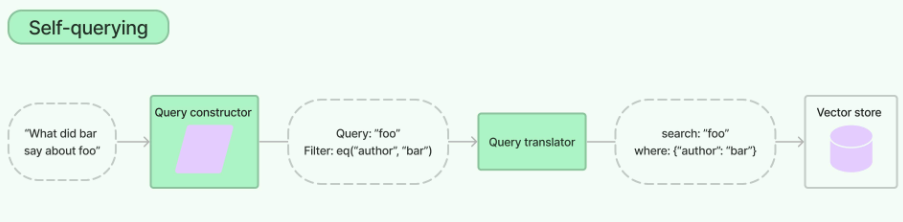

The only class method for the self query base class is `from_llm`. There are four required parameters to create a self query class: </br>

> `LLM` - Passing a language model </br>
> `VectorStore` - Pass a vector store </br>
> `Document_contents` - short description of stored documents </br>
> `Metadata_field_info` - Sequence of AttributeInfo objects, dictionaries containing information about the data in the vector database. We define a list of AttributeInfoobjects which contains information about what each attribute is and its datatype so that the language model knows what it is dealing with. </br>


Self Retrieval is crucial because **relying solely on semantic search for every retrieval task is inefficient**. Semantic search is most effective when the goal is to understand the meaning or intent behind words. However, when performing tasks that involve searching specific data within a database—such as looking up values in structured formats like Excel files or financial data—semantic search is not ideal. It can lead to inaccurate results and unnecessarily consume computational resources. In these situations, LangChain’s Self Querying Retrieval provides a more efficient and accurate solution.

In [41]:
#Identify the metadata parameters to be used to query from the vectorstore

metadata_field_info = [
    AttributeInfo(
        name="year",
        description="Specifies the year of the filing.",
        type="string",
    ),
    AttributeInfo(
        name="quarter",
        description="Specifies the quarter of the filing.",
        type="string",
    ),
    AttributeInfo(
        name="company",
        description="4-letter ticker symbol that identifies a company",
        type="string",
    )
]

#Define a 1-2 line document content description to provide additional context to SelfQueryRetriever
document_content_description = "Quarterly SEC filings (Form 10-Q) of publicly traded companies."


#Define specific LLM model
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")

retriever = SelfQueryRetriever.from_llm(
    llm,
    db,
    document_content_description,
    metadata_field_info,
    enable_limit=True,
    k=4
)

In [42]:
retriever.invoke("What was Apple's total net sales for Q3 2022?")

[Document(metadata={'subject': 'Form 10-Q filed on 2022-07-29 for the period ending 2022-06-25', 'creator': 'EDGAR Filing HTML Converter', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions', 'page_label': '10', 'source': '/content/data/docs/2022 Q3 AAPL.pdf', 'quarter': 'Q3', 'title': '0000320193-22-000070', 'creationdate': '2022-07-29T06:03:21-04:00', 'page': 9, 'keywords': '0000320193-22-000070; ; 10-Q', 'moddate': '2022-07-29T06:03:28-04:00', 'company': 'AAPL', 'year': '2022', 'total_pages': 28, 'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0'}, page_content='Services 19,604 17,486 58,941 50,148 \nTotal net sales $ 82,959 $ 81,434 $ 304,182 $ 282,457 \n(1) Products net sales include amortization of the deferred value of unspecified software upgrade rights, which are bundled in the sales price of the respective\nproduct.\n(2) Wearables, Home and Accessories net sales include sales of AirPods , Apple TV , Apple Watch , Beats  products, HomePod mini  and accessories

In [43]:
# Define prompt for question-answering
prompt = hub.pull("rlm/rag-prompt")

#rlm/rag-prompt
#You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer,
#just say that you don't know. Use three sentences maximum and keep the answer concise.

def format_docs(docs):
    return "\n\n".join(f"{doc.page_content}\n\nMetadata: {doc.metadata}" for doc in docs)

retriever = SelfQueryRetriever.from_llm(
    llm,
    db,
    document_content_description,
    metadata_field_info,
    enable_limit=True,
    k=4
)

# Create a chatbot Question & Answer chain from the retriever
rag_chain_from_docs = (
    RunnablePassthrough.assign(
        context=(lambda x: format_docs(x["context"])))
    | prompt
    | llm
    | StrOutputParser()
)

# Create an end-to-end RAG chain starting with user question all the way through LLM response
rag_chain_with_source = RunnableParallel(
    {"context": retriever, "question": RunnablePassthrough()}
).assign(answer=rag_chain_from_docs)



In [44]:
rag_chain_with_source.invoke("What is AMZN's net sales for Q3 2022?")

{'context': [Document(metadata={'creator': 'EDGAR Filing HTML Converter', 'moddate': '2022-10-28T06:03:45-04:00', 'year': '2022', 'keywords': '0001018724-22-000023; ; 10-Q', 'source': '/content/data/docs/2022 Q3 AMZN.pdf', 'creationdate': '2022-10-28T06:03:36-04:00', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions', 'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0', 'company': 'AMZN', 'subject': 'Form 10-Q filed on 2022-10-28 for the period ending 2022-09-30', 'page_label': '24', 'quarter': 'Q3', 'title': '0001018724-22-000023', 'page': 23, 'total_pages': 50}, page_content='where we record revenue gross. Service sales primarily represent third-party seller fees, which includes commissions and any related fulfillment and shipping\nfees, AWS sales, advertising services, Amazon Prime membership fees, and certain digital content subscriptions. Net sales information is as follows (in\nmillions):\n  Three Months EndedSeptember 30,\nNine Months Ended\nSeptember 30,\n2021 

In [45]:
rag_chain_with_source.invoke("What were the key financial risk factors identified by Nvidia (NVDA) in 2023 Q1, and how might they affect their future profits?")

{'context': [Document(metadata={'subject': 'Form 10-Q filed on 2023-05-26 for the period ending 2023-04-30', 'creator': 'EDGAR Filing HTML Converter', 'total_pages': 49, 'company': 'NVDA', 'page_label': '36', 'year': '2023', 'moddate': '2023-05-26T16:22:32-04:00', 'keywords': '0001045810-23-000093; ; 10-Q', 'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0', 'creationdate': '2023-05-26T16:22:25-04:00', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions', 'title': '0001045810-23-000093', 'source': '/content/data/docs/2023 Q1 NVDA.pdf', 'page': 35, 'quarter': 'Q1'}, page_content='customers’ ability to fulfill their payment obligations to us, our vendors’ ability to fulfill their contractual obligations to us, or our ability to\nfulfill our own obligations.\nAdditionally, we maintain an investment portfolio of various holdings, types, and maturities. These investments are subject to general credit,\nliquidity, market, and interest rate risks, which may be exacerbated by m

## Hybrid Search Retrieval

### Keyword vs Semantic Search

Before we dive into understanding ensemble hybrid retrieval, let's understand the difference between keyword search and semantic search:

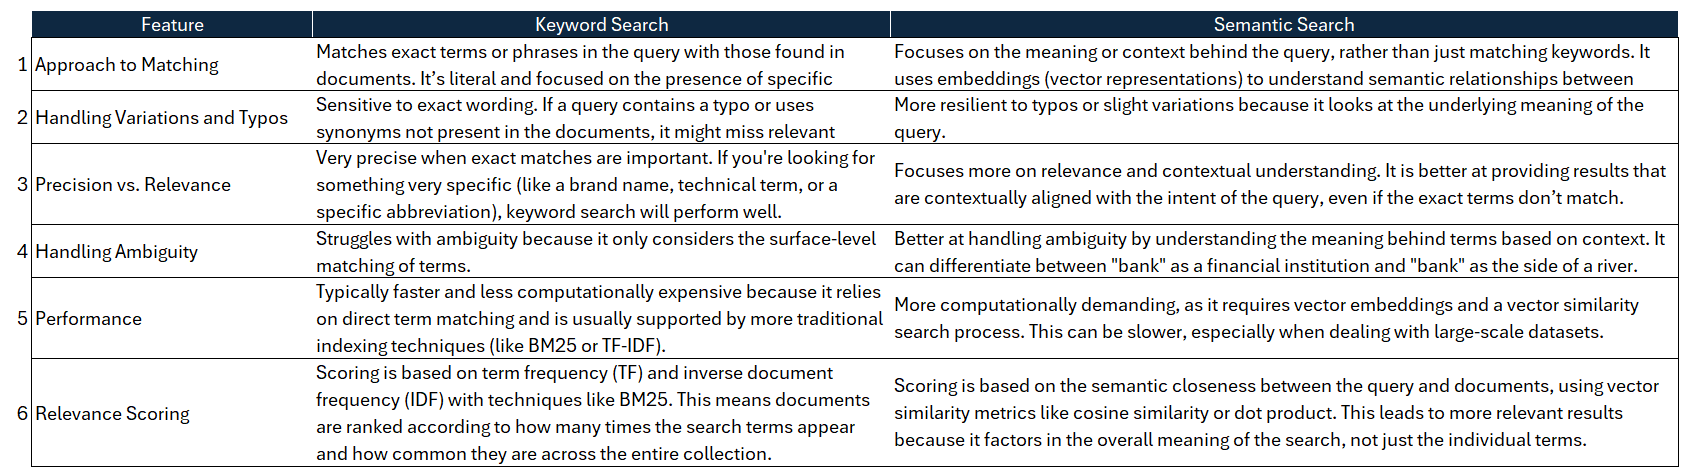

### Hybrid Search

**Hybrid Search** is an approach that combines both vector similarity search and keyword-based search to leverage the strengths of each method while mitigating their weaknesses. It is designed to handle a variety of search scenarios more effectively than using either method on its own.

The `EnsembleRetriever` takes a list of retrievers as input and ensemble the results of their `get_relevant_documents()` methods and rerank the results based on the Reciprocal Rank Fusion algorithm.

By leveraging the strengths of different algorithms, the EnsembleRetriever can achieve better performance than any single algorithm.

The most common pattern is to combine a sparse retriever (like BM25) with a dense retriever (like FAISS similarity), because their strengths are complementary.

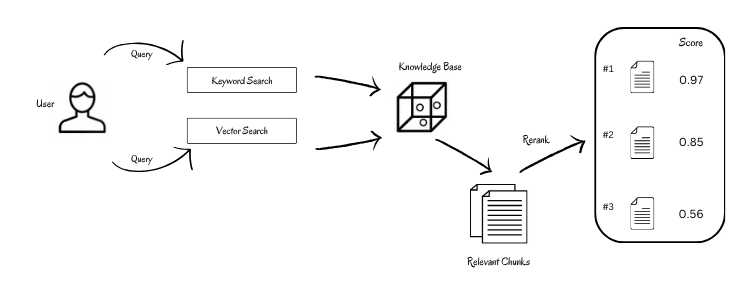

**Benefits of using Hybrid Search**: </br>
- Accuracy and Context - Combines the precision of keyword search (for matching exact terms like names, abbreviations, or code) with the semantic understanding of vector search (to ensure the context and intent are relevant). </br>

- Handling Special Cases - It is especially useful when exact matches (e.g., abbreviations like "GAN" or "names like "Biden") are critical, while still retrieving contextually relevant results based on semantic meaning. </br>

- Improved User Experience - Hybrid search ensures that both the keywords and the underlying intent of the query are taken into account, making it a robust solution for complex search tasks, such as those found in programming, technical documents, or nuanced queries.

**Limitations of using Hybrid Search**: </br>

- Latency - Since hybrid search combines both vector and keyword search, it can be slower compared to using just semantic search, especially with large datasets. </br>

- Computational Expense - Developing and fine-tuning models for hybrid search can be resource-intensive, making it a more costly solution. It’s best suited for scenarios where keyword-based results are crucial. </br>

- Native Support in Databases - Not all vector databases support hybrid search out of the box. You must ensure the database you choose is compatible with this approach. </br>

### Combining Retrievers Together

**Reciprocal Rank Fusion (RRF)** - One of several available methods for combining dense and sparse search scores. RRF ranks each passage according to its place in the keyword and vector outcome lists, and then merges these rankings to generate a unified result list. The RRF score is determined by summing the inverse rankings from each list. Positioning the document’s rank in the denominator imposes a penalty on documents that appear lower in the list.

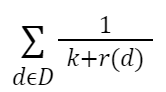

where, </br>

D represents the set of documents </br>
k is a constant </br>
r(d) is the rank of document d </br>

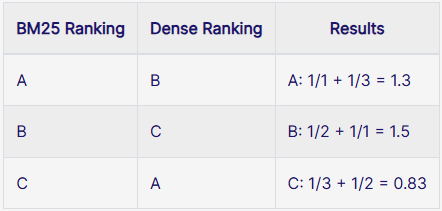

In [46]:
# initialize the bm25 retriever and faiss retriever
bm25_retriever = BM25Retriever.from_documents(final_documents)
bm25_retriever.k = 3

In [47]:
[i.page_content for i in bm25_retriever.invoke("What was the year-over-year growth in net income for Amazon (AMZN) in Q1 2023, and which factors contributed to this change?")]

['which contributed to lower net sales of Services and Mac.\nRest of Asia Pacific\nRest of Asia Pacific net sales decreased during the first quarter of 2023 compared to the same quarter in 2022 due to the weakness in foreign currencies relative\nto the U.S. dollar. The weakness in foreign currencies contributed to lower net sales of iPhone and Mac, which was partially offset by higher net sales of Servicesand iPad.\nProducts and Services Performance',
 'Europe\nEurope net sales decreased during the first quarter of 2023 compared to the same quarter in 2022 due to the weakness in foreign currencies relative to the U.S.dollar, which contributed to lower net sales of iPhone and Mac.\nApple Inc. | Q1 2023 Form 10-Q | 16',
 'Table of Contents\nOther Operating Expense (Income), Net\nOther operating expense (income), net was $249 million and $223 million for Q1 2022 and Q1 2023, and was primarily related to asset impairments for\nphysical store closures in Q1 2022 and for fulfillment network 

In [48]:
embedding = OpenAIEmbeddings()
faiss_vectorstore = FAISS.from_documents(final_documents, embedding)

In [49]:
# Create a retriever from the vectorstore
faiss_retriever = faiss_vectorstore.as_retriever(search_kwargs={"k": 3})

In [50]:
[i.page_content for i in faiss_retriever.invoke("What was the year-over-year growth in net income for Amazon (AMZN) in Q3 2022, and which factors contributed to this change?")]

['International net sales by $1.4 billion for Q3 2023, and reduced International net sales by $1.1 billion for the nine months ended September 30, 2023.\nAWS sales increased 12% in Q3 2023, and 13% for the nine months ended September 30, 2023 compared to the comparable prior year periods. The sales\ngrowth primarily reflects increased customer usage, partially offset by pricing changes, primarily driven by long-term customer contracts.\nOperating Income (Loss)',
 'from our shipping offers. Changes in foreign currency exchange rates impacted International net sales by $(4.9) billion for Q3 2022, and by $(10.2) billion for\nthe nine months ended September 30, 2022.\nAWS sales increased 27% in Q3 2022, and 32% for the nine months ended September 30, 2022 compared to the comparable prior year periods. The sales\ngrowth primarily reflects increased customer usage, partially offset by pricing changes, primarily driven by long-term customer contracts.',
 'fees, AWS sales, advertising services

In [51]:
# initialize the ensemble retriever
ensemble_retriever = EnsembleRetriever(retrievers=[bm25_retriever, faiss_retriever],
                                       weights=[0.5, 0.5])

In [52]:
[i.page_content for i in ensemble_retriever.invoke("What was the year-over-year growth in net income for Amazon (AMZN) in Q3 2022, and which factors contributed to this change?")]

['which contributed to lower net sales of Services and Mac.\nRest of Asia Pacific\nRest of Asia Pacific net sales decreased during the first quarter of 2023 compared to the same quarter in 2022 due to the weakness in foreign currencies relative\nto the U.S. dollar. The weakness in foreign currencies contributed to lower net sales of iPhone and Mac, which was partially offset by higher net sales of Servicesand iPad.\nProducts and Services Performance',
 'International net sales by $1.4 billion for Q3 2023, and reduced International net sales by $1.1 billion for the nine months ended September 30, 2023.\nAWS sales increased 12% in Q3 2023, and 13% for the nine months ended September 30, 2023 compared to the comparable prior year periods. The sales\ngrowth primarily reflects increased customer usage, partially offset by pricing changes, primarily driven by long-term customer contracts.\nOperating Income (Loss)',
 'growth in certain operating expenses, partially offset by increased adverti

In [53]:
[i.page_content for i in ensemble_retriever.invoke("What was the total net sales for Microsoft in 2023 Q1, and which factors contributed to this change?")]


['which contributed to lower net sales of Services and Mac.\nRest of Asia Pacific\nRest of Asia Pacific net sales decreased during the first quarter of 2023 compared to the same quarter in 2022 due to the weakness in foreign currencies relative\nto the U.S. dollar. The weakness in foreign currencies contributed to lower net sales of iPhone and Mac, which was partially offset by higher net sales of Servicesand iPad.\nProducts and Services Performance',
 'Highlights from the first quarter of fiscal year 2023 compared with the first quarter of fiscal year 2022 included:\n • Microsoft Cloud revenue increased 24% to $25.7 billion.\n • Office Commercial products and cloud services revenue increased 7% driven by Office 365 Commercial growth of 11%.\n • Office Consumer products and cloud services revenue increased 7% and Microsoft 365 Consumer subscribers increased to61.3 million.\n • LinkedIn revenue increased 17%.',
 'Europe\nEurope net sales decreased during the first quarter of 2023 compar

In [54]:
# Creates a parallel execution pipeline where the context is retrieved using an ensemble retriever and the question is passed through, with answers generated by the RAG chain from documents
rag_chain_with_source = RunnableParallel(
    {"context": ensemble_retriever, "question": RunnablePassthrough()}
).assign(answer=rag_chain_from_docs)

In [55]:
rag_chain_with_source.invoke("What was the total net sales for Microsoft in 2023 Q1, and which factors contributed to this change?")['answer']

'The total net sales for Microsoft in Q1 2023 decreased by 5% or $6.8 billion compared to the same quarter in 2022. This decline was primarily due to the weakness in foreign currencies relative to the U.S. dollar, which negatively impacted sales. However, there were increases in Microsoft Cloud revenue and Office products, which partially offset the overall decline.'

In [56]:
rag_chain_with_source.invoke("According to Nvidia's (NVDA) 2023 Q2 report, what were the primary challenges identified in their gaming segment, \
                              and how could these affect their market share in the near future?")

{'context': [Document(metadata={'producer': 'Wdesk Fidelity Content Translations Version 007.006.080', 'creator': 'Workiva', 'creationdate': '2023-04-28T16:10:17+00:00', 'moddate': '2023-04-28T16:10:17+00:00', 'title': '04.01.2023 10Q Document', 'author': 'anonymous', 'source': '/content/data/docs/2023 Q1 INTC.pdf', 'total_pages': 43, 'page': 30, 'page_label': '31', 'year': '2023', 'quarter': 'Q1', 'company': 'INTC'}, page_content='Incentives offered to certain customers to compete in the market, accelerate purchases, and to strategically position our products with \ncustomers for market segment share purposes, particularly in CCG, contributed approximately $900 million to our revenue during the first \nquarter of 2023, the impacts of which were contemplated in our financial guidance for Q2 2023 as included in our Form 8-K dated April 27, \n2023.\nTable of Contents\nMD&A 29'),
  Document(id='372a4955-b740-48c8-a090-e8f5747e5479', metadata={'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40

## Reranking

Reranking is a two-stage retrieval process that balances efficiency and effectiveness: </br>

**Initial Retrieval** - A fast, scalable method (like embedding-based similarity search) quickly narrows down a large corpus to a small set of candidate documents.</br>
**Reranking** - A more sophisticated model then reorders these candidates based on their relevance to the query, applying deeper semantic understanding.

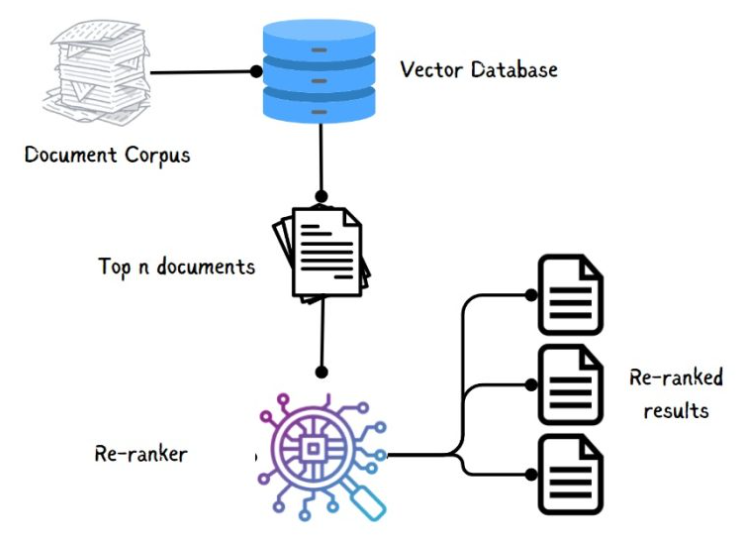

Reranker models, such as Cohere’s `Rerank3`, are specialized AI models that assess and prioritize the relevance of these retrieved documents in relation to a user’s query. Operating on a smaller set of candidate documents, these models focus on fine-tuning rankings based on the context of both the query and the documents. Typically trained on datasets containing examples of relevant and irrelevant documents, rerankers can effectively distinguish high-quality results from less relevant ones. </br>

By integrating reranking into your RAG workflow, you enhance the accuracy and relevance of the information presented, ultimately leading to better responses.

In [57]:
#Setting Cohere API Key within the environment
os.environ['COHERE_API_KEY'] = userdata.get('COHERE_API_KEY')

In [58]:
# Helper function for printing docs
def pretty_print_docs(docs):
    print(
        f"\n{'-' * 100}\n".join(
            [f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]
        )
    )

In [59]:
#Define embedding model
# embeddings = OpenAIEmbeddings(model="text-embedding-3-large", dimensions = 1024)

# # Define a vector store DB
# db = Chroma.from_documents(final_documents, embeddings,
#                            persist_directory='/content/chroma_db')

# Create a retriever object from the vector db
retriever = db.as_retriever(search_kwargs={'k': 20})

In [60]:
query = "What were the key operating expenses for Apple (AAPL) in Q3 2023, and how do they compare to the previous quarter or year?"
docs = retriever.invoke(query)
pretty_print_docs(docs)

Document 1:

Other corporate expenses, net (1,710) (1,608) (5,422) (4,743)
Total operating income $ 23,076 $ 24,126 $ 94,543 $ 85,163 
Apple Inc. | Q3 2022 Form 10-Q | 13
----------------------------------------------------------------------------------------------------
Document 2:

Other corporate expenses, net (1,650) (1,710) (5,043) (5,422)
Total operating income $ 22,998 $ 23,076 $ 87,332 $ 94,543 
Apple Inc. | Q3 2023 Form 10-Q | 13
----------------------------------------------------------------------------------------------------
Document 3:

A reconciliation of the Company’s segment operating income to the Condensed Consolidated Statements of Operations for the three months ended December
31, 2022 and December 25, 2021 is as follows (in millions):
Three Months Ended
December 31,2022 December 25,2021
Segment operating income $ 45,405 $ 49,657 
Research and development expense (7,709) (6,306)
Other corporate expenses, net (1,680) (1,863)
Total operating income $ 36,016 $ 41,488 

The `ContextualCompressionRetriever` is a custom retrieval-enhanced model designed to combine a base retriever with a compressor to improve the quality and relevance of search results. </br>

`base_compressor` refers to a Cohere Rerank model ("rerank-english-v3.0") which is a specialized model for reranking search results. This model ranks candidate documents retrieved by the base retriever based on their relevance to a query, improving result accuracy by providing a deeper, context-driven understanding.
base_retriever is typically a retriever model (like a vector search model) that pulls relevant documents from a database. </br>

The `ContextualCompressionRetriever` combines the efficiency of the base retriever with the reranking power of the Cohere Rerank model, creating a more contextually relevant set of results.

In [61]:
# Initialize a Cohere LLM and a contextual compression retriever using a Cohere reranker for improved retrieval and ranking
compressor = CohereRerank(model="rerank-english-v3.0")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever
)

In [62]:
compressed_docs = compression_retriever.invoke(
    "What were the key operating expenses for Apple (AAPL) in Q3 2023, and how do they compare to the previous quarter or year?"
)
pretty_print_docs(compressed_docs)

Document 1:

Other corporate expenses, net (1,650) (1,710) (5,043) (5,422)
Total operating income $ 22,998 $ 23,076 $ 87,332 $ 94,543 
Apple Inc. | Q3 2023 Form 10-Q | 13
----------------------------------------------------------------------------------------------------
Document 2:

Third Quarter of Fiscal Year 2024 Summary
Three Months Ended
 October 29,2023 July 30, 2023 October 30,2022 Quarter-over-QuarterChange Year-over-YearChange
($ in millions, except per share data)
Revenue $ 18,120 $ 13,507 $ 5,931 34 % 206 %
Gross margin 74.0 % 70.1 % 53.6 % 3.9 pts 20.4 pts
Operating expenses $ 2,983 $ 2,662 $ 2,576 12 % 16 %
Operating income $ 10,417 $ 6,800 $ 601 53 % 1,633 %
Net income $ 9,243 $ 6,188 $ 680 49 % 1,259 %
----------------------------------------------------------------------------------------------------
Document 3:

Research and Development $B Marketing, General, and Administrative $B
(Percentages in chart indicate operating expenses as a percentage of total revenue)
 
  

In the below given code snippet, the [`RetrievalQA.from_chain_type`](https://python.langchain.com/docs/versions/migrating_chains/retrieval_qa/) is used to create a Retrieval-Based Question Answering (QA) Chain with the Cohere LLM model and Compression Retriever.

In [63]:
#Define pre-existing RAG chain
chain = RetrievalQA.from_chain_type(
    llm=Cohere(temperature=0), retriever=compression_retriever
)

In [64]:
query = "What were the key operating expenses for Apple (AAPL) in Q3 2023, and how do they compare to the previous quarter or year?"
chain({"query": query})

{'query': 'What were the key operating expenses for Apple (AAPL) in Q3 2023, and how do they compare to the previous quarter or year?',
 'result': " Apple's operating expenses for Q3 2023 were $2,983 million compared to $2,662 million in Q3 2022, representing an increase of 12%. The increase is also noticeable when comparing the data to the previous year, with a 16% increase from $2,576 million in Q3 2021. \n\nHowever, the company's research and development (R&D) expenses decreased from Q3 2022 to Q3 2023. The decrease, which was valued at $432 million, represented a 10% decline. This drop was attributed to the implementation of cost-cutting measures and higher incentive-based cash compensation. \n\nWhen we look at the bigger picture, the year-to-date (YTD) comparison from January to the end of September 2023, we see that Apple's R&D expenses still experienced a decrease. The overall decrease was $1 billion, representing an 8% decline. \n\nIt's important to note that these percentages 

**Re-ranking Best Practices**: </br>
- Tune Reranker Parameters - Experiment with different reranking thresholds and document quantities, and consider using ensemble models for better results.
- Preprocess Effectively - Ensure consistent text cleaning and normalization, and apply domain-specific NLP techniques for better matching.
- Monitor and Retrain - Track reranker performance over time and periodically retrain to adapt to new data and avoid concept drift.
- Address Potential Biases - Regularly audit for biases in the reranker and ensure fairness across different quer bold texty types and document categories.

## Conclusion

Retrieval-Augmented Generation (RAG) systems combine information retrieval techniques with generative models to enhance the quality of generated responses. Key takeaways include the importance of context fulfillment, which ensures search results align with user intent, and query rewriting, which improves result relevance by adjusting queries for better matching. Reranking techniques allow for reordering results based on deeper semantic understanding, while hybrid search merges keyword and vector-based searches to balance precision and semantic relevance. Additionally, self-querying enables dynamic, context-aware data retrieval, improving the system's adaptability and accuracy.